In [1]:

import torch
import matplotlib.pyplot as plt
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from pathlib import Path
import numpy as np


# WandB setup
from kaggle_secrets import UserSecretsClient
wandb_key = UserSecretsClient().get_secret("wandb_api")

import wandb
wandb.login(key=wandb_key)
wandb.init(
    project="yale_gwi25",  
    name="yale_gwi25_v1",
    tags=[ "FWI", "VAE"],
    notes="This run is for training the FWI VAE model on seismic data."
)

wandb: Using wandb-core as the SDK backend.  Please refer to https://wandb.me/wandb-core for more information.
wandb: Currently logged in as: farrukhmehmood-nts (farrukhmehmood-nts-the-islamia-university-of-bahawalpur). Use `wandb login --relogin` to force relogin
wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc


In [2]:
def get_all_input_output_files(base_dir):
    base_dir = Path(base_dir)
    input_files = sorted([f for f in base_dir.rglob('*.npy') if 'data' in f.name or 'seis' in f.name])
    output_files = [Path(str(f).replace('data', 'model').replace('seis', 'vel')) for f in input_files]
    return input_files, output_files

class SeismicDataset(Dataset):
    def __init__(self, input_files, output_files, mean=None, std=None, n_examples_per_file=500, normalize=True):
        self.input_files = input_files
        self.output_files = output_files
        self.n_examples_per_file = n_examples_per_file
        self.normalize = normalize

        self.mean = mean
        self.std = std

        # Compute stats only if not provided
        if self.normalize and (mean is None or std is None):
            self.mean, self.std = self._compute_mean_std()

    def __len__(self):
        return len(self.input_files) * self.n_examples_per_file

    def __getitem__(self, idx):
        file_idx = idx // self.n_examples_per_file
        sample_idx = idx % self.n_examples_per_file

        X = np.load(self.input_files[file_idx], mmap_mode='r')[sample_idx]
        y = np.load(self.output_files[file_idx], mmap_mode='r')[sample_idx]

        # Normalize X
        if self.normalize:
            X = (X - self.mean) / self.std

        return torch.tensor(X, dtype=torch.float32), torch.tensor(y, dtype=torch.float32)

    def _compute_mean_std(self, max_files=10):
        print("Computing mean/std from sample files...")
        all_samples = []
        for i in range(min(max_files, len(self.input_files))):
            X = np.load(self.input_files[i], mmap_mode='r')[:100]  # Take a few samples only
            all_samples.append(X)
        all_samples = np.concatenate(all_samples, axis=0)
        mean = np.mean(all_samples)
        std = np.std(all_samples)
        return mean, std


def denormalize(pred, mean, std):
    return pred * std + mean



# 1. Get all file paths
base_dir = "/kaggle/input/waveform-inversion/train_samples"
all_inputs, all_outputs = get_all_input_output_files(base_dir)

# 2. Split into train/valid
train_inputs, valid_inputs, train_outputs, valid_outputs = train_test_split(
    all_inputs, all_outputs, test_size=0.2, random_state=42
)

# 3. Create train dataset (will compute mean/std)
dstrain = SeismicDataset(train_inputs, train_outputs, normalize=True)

# 4. Pass same mean/std to validation
dsvalid = SeismicDataset(valid_inputs, valid_outputs, mean=dstrain.mean, std=dstrain.std)

# 5. Create loaders
train_loader = DataLoader(dstrain, batch_size=64, shuffle=True, pin_memory=True, num_workers=4, drop_last=True)
valid_loader = DataLoader(dsvalid, batch_size=64, shuffle=False, pin_memory=True, num_workers=4, drop_last=False)

Computing mean/std from sample files...


## Model


In [3]:
class U_Net(nn.Module):
    def __init__(self):
        super().__init__()
        
        # Encoder (downsampling)
        self.block_down1=nn.Sequential(
            nn.Conv2d(5,64,kernel_size=(7,1),stride=1),
            nn.Conv2d(64,64,kernel_size=(7,1),stride=1),
            nn.MaxPool2d(kernel_size=(2,1)))
        
        self.block_down2=nn.Sequential(
            nn.Conv2d(64,128,kernel_size=(7,1),stride=1),
            nn.Conv2d(128,128,kernel_size=(7,1),stride=1),)
        
        self.block_down3=nn.Sequential(
            nn.Conv2d(128,256,kernel_size=(7,1),stride=1),
            nn.Conv2d(256,256,kernel_size=(7,1),stride=(2,1)),
            nn.MaxPool2d(kernel_size=(2,1)))
        
        self.block_down4=nn.Sequential(
            nn.Conv2d(256,512,kernel_size=(7,1),stride=1),
            nn.Conv2d(512,512,kernel_size=(7,1),stride=(2,1)),
            nn.MaxPool2d(kernel_size=(2,1)))
        
        self.block_down5=nn.Sequential(
            nn.Conv2d(512,1024,kernel_size=(7,1),stride=1),)
        
        self.block_up5 = nn.Sequential(
            nn.ConvTranspose2d(1024,512,kernel_size=(5,1),stride=1)
        )
        self.block_up4 = nn.Sequential(
            nn.ConvTranspose2d(512,256,kernel_size=(5,1),stride=1)
        )
        self.block_up3 = nn.Sequential(
            nn.ConvTranspose2d(256,128,kernel_size=(5,1),stride=1)
        )
        self.block_up2 = nn.Sequential(
            nn.ConvTranspose2d(128,64,kernel_size=(5,1),stride=1)
        )
        self.block_up1 = nn.Sequential(
            nn.ConvTranspose2d(64,1,kernel_size=(5,1),stride=(2,1)),
            nn.AdaptiveAvgPool2d(70)
        )
    def forward(self, x, ground_truth=None):
        ground_truth_pooled=torch.tensor([0])
        x = self.block_down1(x)
        x = self.block_down2(x)
        x = self.block_down3(x)
        x = self.block_down4(x)
        x = self.block_down5(x)

        if  ground_truth != None:
            
            # pool = nn.AvgPool2d(kernel_size=(32, 1), stride=(2, 1))
            # ground_truth_pooled = pool(ground_truth).repeat(1, 1024, 1, 1)
            # x = x+ground_truth_pooled
            x = self.block_up5(x)

            
            # pool = nn.AvgPool2d(kernel_size=(24, 1), stride=(2, 1))
            # ground_truth_pooled = pool(ground_truth).repeat(1, 512, 1, 1)
            # x = x+ground_truth_pooled
            x = self.block_up4(x)
            
            # pool = nn.AvgPool2d(kernel_size=(16, 1), stride=(2, 1))
            # ground_truth_pooled = pool(ground_truth).repeat(1, 256, 1, 1)
            # x = x+ground_truth_pooled
            x = self.block_up3(x)

            pool = nn.AvgPool2d(kernel_size=(8, 1), stride=(2, 1))
            ground_truth_pooled = pool(ground_truth).repeat(1, 128, 1, 1)
            x = x+ground_truth_pooled
            x = self.block_up2(x)

            pool =  nn.AvgPool2d(kernel_size=(35, 1), stride=(1, 1))
            ground_truth_pooled = pool(ground_truth).repeat(1, 64, 1, 1)
            x = x+ground_truth_pooled
            x = self.block_up1(x)

        else:
            
            x = self.block_up5(x)
            x = self.block_up4(x)
            x = self.block_up3(x)
            x = self.block_up2(x)
            x = self.block_up1(x)


        return x


## Training Setup

In [4]:
from tqdm import tqdm


def compute_epoch_loss(model, data_loader, loss_fn, device):
    model.eval()
    curr_loss, num_examples = 0., 0
    with torch.no_grad():
        for features, v_map_true in data_loader:
            features = features.to(device)
            v_map_true = v_map_true.to(device)
            v_map_pred = model(features)

            batch_size = features.size(0)

            data_loss = loss_fn(v_map_pred, v_map_true, reduction='none')
            data_loss = data_loss.view(batch_size, -1).sum(axis=1).mean()

            
            curr_loss += data_loss.item() * features.size(0)
            num_examples += features.size(0)

    return curr_loss / num_examples

def train_vae(num_epochs, model, optimizer, device, train_loader, valid_loader,
              loss_fn=None,):

    if loss_fn is None:
        loss_fn = F.l1_loss

    for epoch in range(num_epochs):
        model.train()
        train_loss_accum = 0
        pbar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{num_epochs}")

        for batch_idx, (features, v_map_true) in enumerate(pbar):
            features = features.to(device)
            v_map_true = v_map_true.to(device)
            v_map_pred = model(features,v_map_true)

            batch_size = features.size(0)

            data_loss = loss_fn(v_map_pred, v_map_true, reduction='none')
            data_loss = data_loss.view(batch_size, -1).sum(axis=1).mean()


            total_loss = data_loss

            optimizer.zero_grad()
            total_loss.backward()
            optimizer.step()

            # Logging
            pbar.set_postfix({'loss': total_loss.item()})
            wandb.log({
                # 'train/total_loss': total_loss.item(),
                'train/data_loss': data_loss.item(),
                'epoch': epoch + 1
            })

        # Validation step
        val_loss = compute_epoch_loss(model, valid_loader, loss_fn, device)
        wandb.log({'val/total_loss': val_loss, 'epoch': epoch + 1})
        print(f"Epoch {epoch+1} - Validation Loss: {val_loss:.4f}")

    wandb.finish()


In [5]:
device = "cuda" if torch.cuda.is_available() else 'cpu'
model = U_Net().to(device)
optimizer = torch.optim.Adam(params=model.parameters(), lr=0.0005)

train_vae(
    num_epochs=30,
    model=model,
    optimizer=optimizer,
    device=device,
    train_loader=train_loader,
    valid_loader=valid_loader,
)


Epoch 1/30: 100%|██████████| 125/125 [07:14<00:00,  3.48s/it, loss=2.86e+6]


Epoch 1 - Validation Loss: 13917319.3920


Epoch 2/30: 100%|██████████| 125/125 [07:13<00:00,  3.47s/it, loss=4.95e+6]


Epoch 2 - Validation Loss: 14958431.5840


Epoch 3/30: 100%|██████████| 125/125 [07:13<00:00,  3.47s/it, loss=3.57e+6]


...

Epoch 15 - Validation Loss: 14791456.2880


Epoch 16/30: 100%|██████████| 125/125 [07:14<00:00,  3.47s/it, loss=1.29e+6]


Epoch 16 - Validation Loss: 14376428.8080


Epoch 17/30:  47%|████▋     | 59/125 [03:28<03:53,  3.54s/it, loss=7.03e+5]


KeyboardInterrupt: 

In [ ]:
# Save model
torch.save(model.state_dict(), 'vae_model.pth')

# Then, download using Kaggle utility
from IPython.display import FileLink
FileLink('vae_model.pth')


In [ ]:
import wandb

# Start a W&B run
wandb.init(   project="yale_gwi25",  
    name="yale_gwi25_v1",)

# Save your model
torch.save(model.state_dict(), "vae_model.pth")

# Create and log the artifact
artifact = wandb.Artifact("fwi_vae_model", type="model")
artifact.add_file("vae_model.pth")
wandb.log_artifact(artifact)

# Optionally finish the run
wandb.finish()


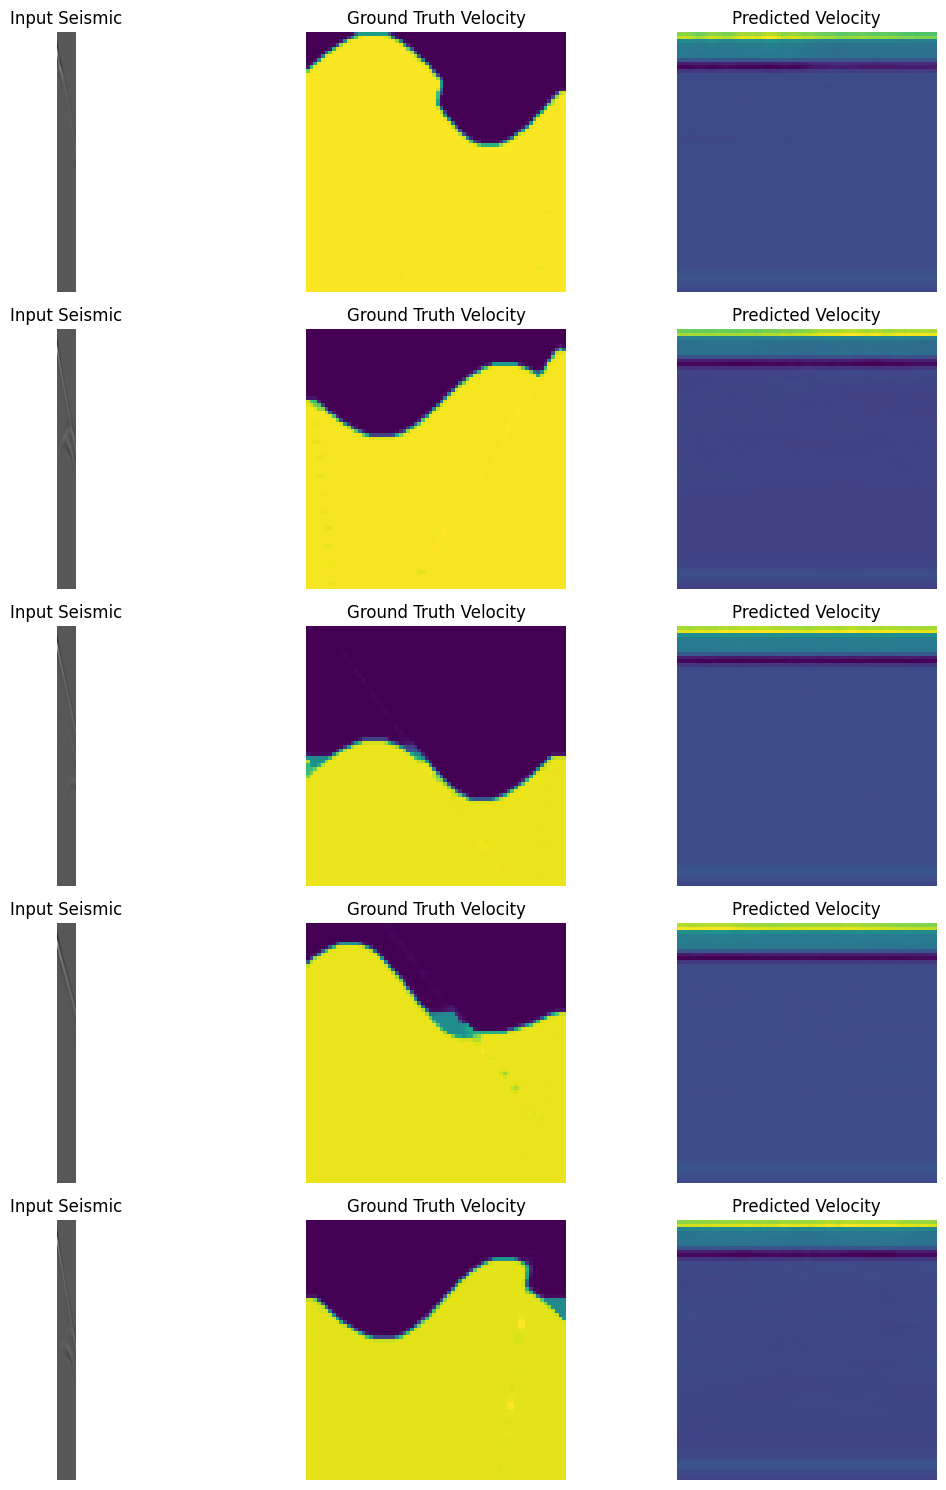

In [8]:
import random
import matplotlib.pyplot as plt

# Set model to evaluation mode
model.eval()

# Get one batch from the validation loader
features_batch, targets_batch = next(iter(valid_loader))

# Move to the same device as model
features_batch = features_batch.to(device)

# Choose 5 random indices from the batch
random_indices = random.sample(range(features_batch.size(0)), 5)

# Run inference
with torch.no_grad():
    predictions = model(features_batch)

# Move data to CPU for visualization
inputs = features_batch.cpu()
predictions = predictions.cpu()
targets = targets_batch.cpu()

# Plotting
fig, axs = plt.subplots(5, 3, figsize=(12, 15))
for i, idx in enumerate(random_indices):
    axs[i, 0].imshow(inputs[idx][0], cmap='gray')  # assuming first channel is representative
    axs[i, 0].set_title("Input Seismic")
    axs[i, 1].imshow(targets[idx][0], cmap='viridis')
    axs[i, 1].set_title("Ground Truth Velocity")
    axs[i, 2].imshow(predictions[idx][0], cmap='viridis')
    axs[i, 2].set_title("Predicted Velocity")

for ax_row in axs:
    for ax in ax_row:
        ax.axis('off')

plt.tight_layout()
plt.show()
